# **HOSPITAL BEDS MANAGEMENT**

#**Import Library**

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# **Business Understanding**

**Business Objective**

  Rumah Sakit ini ingin tahu bagaimana cara mengatur staf, tempat tidur dan lyanannya agar sesuai dengan jumlah pasien.

  Tujuannya supaya pelayanan lebih lancar, tidak ada kekurangan satf atau tempat tidur, pasien bisa ditanganin secara baik dan membantu rumah sakit mengelola sumber daya dengan lebih baik.

  Dengan tercapainya tujuan tersebut, rumah sakit diharapkan dapat memberikan pelayanan yang lebih efisien, cepat, dan berkualitas kepada pasien.


**Assess Situation**



Rumah sakit sebagai instuasi pelayanan kesehatan menghadapi tantangan dalam mengelola sumber daya secara optimal, terutama tenaga medis dan fasilitas tempat tidur. permintaan pasien yang tidak stabil dapat menyebabkan ketidak seimbangan antara kapasitas layanan dan kebutuhan pasien, sehingga berdampak pada kualitas pelayanan dan efisiensi oprasional.


Dataset rumah sakit sintetis ini disediakan untuk mensimulasikan kondisi operasional sumah sakit berukuran sedang, sehingga dapat digunaan sebagai bahan anlisis tanpa menggunakan data pasien nyata(untuk menjaga privasi).

adapun masalah yang dihadapi:
*   tenaga kerja yang tidak merata antar unit layanan.
*   kelebihan atau kekurangan kapasitas tempat tidur pada unit tertentu.
*   lonjakan penerimaan pasien yang tidak diantisipasi dengan baik





**Analytic Goals**

Jadi tujuan yang ingin dicapai dari sisi analisis data(bukan tujuan bisnis, tapi tujuan teknis datanya)

*  Menghitung rasio
  pasien dibandikan staf dan Tempat tidur

*  Menganalisis Pola pasien
  mengetahui  jumlah pasien,karakteristik pasien, dan pola kunjungan

*  Menganalisis penggunaan tempat tidur
  mengetahui unit mana yang sering penuh dan mana yang jarang digunkan

*  Menganalisis distribusi tenaga kerja
  melihat apakah jumlah staf sudah seimbang dengan jumlah pasien, Membuat Perkiraan staf jika jumlah pasien meningkat

*   Mencari pola dan insight penting
  misalnya waktu ramai pasien, unit dengan beban tinggi, dan potensi masalah layanan.





**Project Plan**

Project plan menjelaskan tahapan yang akan dilakukan dalam analisis data.

*   Langkah 1: Pahami Data

    Melihatihat isi dataset, jumlah baris/kolom, dan tipe data.
*   Langkah 2: Siapkan Data

    Bersihkan data dari nilai kosong/duplikat, ubah data kategorialkan jadi angka jika perlu

*   Langkah 3: Analisis dan Modeling

    Hitung rasio pasien/staf, Pasien/Tempat Tidur, buat grafik, dan coba model prediksi sederhana.

*   Langkah 4: Evaluasi

    Melihat hasil analisis, tentukan dapartemen yang paling sibuk, dan buat rekomendasi









#**DATA UNDERSTANDING**

##**Memuat Dataset**

In [29]:
path = "/content/drive/MyDrive/AVD/patients.csv"
df = pd.read_csv(path)
df

,patient_id,name,age,arrival_date,departure_date,service,satisfaction
0,PAT-09484753,Richard Rodriguez,24,2025-03-16,2025-03-22,surgery,61
1,PAT-f0644084,Shannon Walker,6,2025-12-13,2025-12-14,surgery,83
2,PAT-ac6162e4,Julia Torres,24,2025-06-29,2025-07-05,general_medicine,83
3,PAT-3dda2bb5,Crystal Johnson,32,2025-10-12,2025-10-23,emergency,81
4,PAT-08591375,Garrett Lin,25,2025-02-18,2025-02-25,ICU,76
...,...,...,...,...,...,...,...
995,PAT-a01bf534,Amber Vang,26,2025-12-02,2025-12-04,emergency,91
996,PAT-87fa07bd,Martha Smith,89,2025-11-18,2025-11-30,emergency,99
997,PAT-8f07e894,Jennifer James,72,2025-12-12,2025-12-21,ICU,69
998,PAT-4ae301e1,Kara Hernandez,47,2025-02-08,2025-02-20,ICU,61


#**Deskripsi Data**

##**Informasi Data**

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-null   object
 4   departure_date  1000 non-null   object
 5   service         1000 non-null   object
 6   satisfaction    1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


Berdasarkan data diatas dataset ini memiliki 1000 baris dan 7 kolom

##**Informasi Lanjutan**

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   patient_id      1000 non-null   object
 1   name            1000 non-null   object
 2   age             1000 non-null   int64 
 3   arrival_date    1000 non-null   object
 4   departure_date  1000 non-null   object
 5   service         1000 non-null   object
 6   satisfaction    1000 non-null   int64 
dtypes: int64(2), object(5)
memory usage: 54.8+ KB


1. Patient_id: Jumlah baris: 1000 Tipe data: Object
2. Name: Jumlah baris: 1000 Tipe data: Object
3. age: Jumlah baris: 1000 Tipe data: Intj64
4. Arrival_date: Jumlah baris: 1000 Tipe data: Object
5. Daparture_date: Jumlah baris: 1000 Tipe data: Object
6. Service: Jumlah baris: 1000 Tipe data: Object
7. Statisfaction: Jumlah baris: 1000 Tipe data: Int64



##**Informasi Statistik Deskriftif**

In [32]:
df.describe(include="all")

,patient_id,name,age,arrival_date,departure_date,service,satisfaction
count,1000,1000,1000.000000,1000,1000,1000,1000.000000
unique,1000,993,NaN,344,337,4,NaN
top,PAT-e2ef9c5f,Michael Miller,NaN,2025-01-19,2025-10-16,emergency,NaN
freq,1,2,NaN,9,8,263,NaN
mean,NaN,NaN,45.337000,NaN,NaN,NaN,79.597000
std,NaN,NaN,25.999912,NaN,NaN,NaN,11.550325
min,NaN,NaN,0.000000,NaN,NaN,NaN,60.000000
25%,NaN,NaN,23.000000,NaN,NaN,NaN,70.000000
50%,NaN,NaN,46.000000,NaN,NaN,NaN,80.000000
75%,NaN,NaN,68.000000,NaN,NaN,NaN,89.250000


1. Count berdasarkan data, total baris ada 1000.
*   Profit Lengkap Tidak ada data yang hilang
*   Tidak Terdapat MIssing Velues terhadap kolom, Patient_id, Name, Age, Arrival_date, Departure_date, Service, Satisfaction.



---

2. Mean vs Median

*   Kolom age
    Mean = 45.337
    Median =46.000
  Nilai median hampir sama dengan mean menunjukan distribusi umur relatif seimbang.

*   Kolom satisfaction
    Mean = 79.597
    Median =80.000
  Rata rata tingkat kepuasan pasien menunjukan tergolong tinggi. hal ini mengindikasikan kualitascpelayanan rumah sakit dalam dataset tergolong baik.

Kesimpulannya: Dataset ini menunjukan bahwa pasien berasal dari berbagai usia, dengan dominan usia dewasa, tingkat kepuasan pasien relatif tinggi dan stabil, rumah sakit secara umum memiliki performa pelayanan yang baik menurut sintetis ini.




---


3. min dan max

*   Age
    min = 0
    max = 89.000
*   Satisfaction
    min = 60.000
    max = 99.000

Kesimpulannya:


*   Rentang usia pasien sangat luas (0–89 tahun), menunjukkan rumah sakit melayani semua kelompok usia.

*   Tingkat kepuasan pasien berada pada rentang yang baik (60–99), yang menandakan kualitas layanan rumah sakit tergolong baik.




4. Standar Deviasi(std)
    

*   Age
    Mean = 45.337
    Std = 25.999


*   Statisfasion
    Mean = 79.597
    Std = 11.550

Kesimpulan:
*   Variasi usia Pasien tinggi, Rumah sakit melayani banyak kelompok usia.
*   Variasi kepuasan pasien rendah, Pelayanan rumah sakit dinilai cukup
konsisten oleh pasien.















## **Verivikasi Kualitas Data**

### **Data Type Check**

Pemeriksaan tipe data dilakukan untuk memastikan setiap kolom memiliki tipe data yang sesuai dengan maknanya, sehingga data dapat dianalisis dengan benar.



In [33]:
df.dtypes

,0
patient_id,object
name,object
age,int64
arrival_date,object
departure_date,object
service,object
satisfaction,int64


### **Incosistent Values**

Inconsistent values adalah perbedaan penulisan data kategori yang seharusnya sama.

1. **Name**

pada kolom ini terdapat potensi nilai tidak konsisten karena perbedaan format penulisan nama (huruf kapital dan spasi). Namun, perbedaan ini tidak mempengaruhi analisis numerik, tetapi dapat mempengaruhi analisis berbasis identitas individu.

In [34]:
print(df['name'].unique())

['Richard Rodriguez' 'Shannon Walker' 'Julia Torres' 'Crystal Johnson'
 'Garrett Lin' 'Diana May' 'William Herrera' 'Ashley Waller'
 'Victor Baker' 'Jeffrey Chandler' 'Larry Dixon' 'Kenneth Scott'
 'April Frost' 'Michelle Harmon' 'Helen Jones' 'Erin Edwards'
 'Michelle Evans' 'Jason Powell' 'Cameron Fisher' 'Megan Orr'
 'Elizabeth Kelley' 'Dustin Jordan' 'Mary Marshall' 'Daniel Kennedy'
 'Rebecca Jackson' 'Jose Schultz' 'Robert Potter' 'Courtney Gonzalez'
 'David Alvarez' 'Angel Perry' 'Cheyenne Horton' 'David Douglas Jr.'
 'Patricia Rodriguez' 'Christopher Rubio' 'Amber Wright' 'Joyce Solis'
 'Victoria Larson' 'Stephanie Salazar' 'Kathy Rivas' 'Stephanie Manning'
 'David Wright' 'Pamela Boyd' 'Denise Jones' 'Devon Flores' 'Brenda Hall'
 'Michelle Brown' 'Joshua Perry' 'Jason Stein' 'Melissa Gates'
 'Jamie Smith' 'Paul Castaneda' 'Jennifer Adkins' 'Lindsey Walker'
 'Jeffrey Johnson' 'Michael Powell' 'John Anderson' 'Alyssa Long'
 'Alyssa Day' 'Joel Williams' 'Daniel Murphy' 'Jamie Walt

2. **arrival_date**

Pada kolom ini ditemukan variasi format tanggal yang berbeda. Perbedaan format ini dapat menyebabkan kesalahan dalam analisis waktu, sehingga perlu dilakukan standarisasi format tanggal (misalnya YYYY-MM-DD).

In [35]:
print(df['arrival_date'].unique())

['2025-03-16' '2025-12-13' '2025-06-29' '2025-10-12' '2025-02-18'
 '2025-06-26' '2025-12-26' '2025-05-21' '2025-07-30' '2025-11-01'
 '2025-01-19' '2025-06-24' '2025-11-15' '2025-02-24' '2025-06-11'
 '2025-10-15' '2025-11-09' '2025-09-12' '2025-08-27' '2025-04-02'
 '2025-03-29' '2025-06-14' '2025-11-07' '2025-06-10' '2025-02-05'
 '2025-10-30' '2025-07-14' '2025-10-20' '2025-02-22' '2025-10-07'
 '2025-02-28' '2025-04-25' '2025-08-25' '2025-10-05' '2025-01-29'
 '2025-12-22' '2025-04-27' '2025-09-25' '2025-07-09' '2025-07-12'
 '2025-05-29' '2025-06-13' '2025-10-16' '2025-08-15' '2025-12-31'
 '2025-03-14' '2025-08-05' '2025-02-08' '2025-04-12' '2025-02-13'
 '2025-08-04' '2025-08-03' '2025-01-25' '2025-09-23' '2025-03-27'
 '2025-11-11' '2025-04-13' '2025-04-18' '2025-06-20' '2025-12-30'
 '2025-07-29' '2025-09-04' '2025-04-06' '2025-08-24' '2025-12-25'
 '2025-11-20' '2025-07-06' '2025-07-17' '2025-11-29' '2025-09-17'
 '2025-03-04' '2025-08-29' '2025-09-18' '2025-04-09' '2025-03-03'
 '2025-03-

3. **Daparture_date**

Terdapat potensi nilai tidak konsisten akibat perbedaan format tanggal dan kemungkinan kesalahan logika waktu, seperti tanggal keluar lebih awal dari tanggal masuk. Data tersebut perlu diperbaiki atau dihapus karena dapat menyebabkan kesalahan perhitungan lama tinggal pasien

In [36]:
print(df['departure_date'].unique())

['2025-03-22' '2025-12-14' '2025-07-05' '2025-10-23' '2025-02-25'
 '2025-06-30' '2025-12-27' '2025-06-04' '2025-08-13' '2025-11-14'
 '2025-01-21' '2025-06-26' '2025-11-19' '2025-03-03' '2025-06-23'
 '2025-10-17' '2025-11-16' '2025-09-25' '2025-09-01' '2025-04-10'
 '2025-04-12' '2025-06-20' '2025-11-09' '2025-06-17' '2025-02-18'
 '2025-11-04' '2025-07-21' '2025-10-26' '2025-03-06' '2025-10-08'
 '2025-03-14' '2025-04-26' '2025-09-03' '2025-10-16' '2025-02-11'
 '2025-12-31' '2025-05-07' '2025-11-15' '2025-07-19' '2025-07-15'
 '2025-06-09' '2025-06-14' '2025-03-04' '2025-08-19' '2026-01-11'
 '2025-03-23' '2025-08-18' '2025-04-14' '2025-02-24' '2025-11-08'
 '2025-08-07' '2025-08-08' '2025-01-27' '2025-03-10' '2025-09-30'
 '2025-04-06' '2025-05-04' '2025-11-18' '2025-04-30' '2025-06-28'
 '2026-01-06' '2025-07-30' '2025-11-10' '2025-09-17' '2025-04-09'
 '2025-02-12' '2025-09-02' '2025-09-05' '2025-12-29' '2025-06-29'
 '2025-11-22' '2025-07-17' '2025-07-16' '2025-07-24' '2025-12-01'
 '2025-09-

4. **Service**

Kolom Service biasanya kategori layanan, inconsistency terjadi karena
Penulisan berbeda, Singkatan, dan Typo.

In [37]:
print(df['service'].unique())

['surgery' 'general_medicine' 'emergency' 'ICU']


### **Missing Values**

Missing values adalah data yang kosong atau tidak terisi (NULL/NaN).
Pada tahap ini bisa melihat berapa banyak daya yang kosong.

In [38]:
pd.DataFrame(df.isna().sum() / len(df) * 100, columns=['non-null'])

,non-null
patient_id,0.0
name,0.0
age,0.0
arrival_date,0.0
departure_date,0.0
service,0.0
satisfaction,0.0


### **Duplicated Values**

Duplicate values adalah baris data yang sama persis muncul lebih dari satu kali. hal ini dilakukan Dataset bebas dari redundansi data sehingga analisis tidak bias.

In [39]:
df[df.duplicated()]

,patient_id,name,age,arrival_date,departure_date,service,satisfaction


Pada data ini, Setiap Patient_ID bersifat unik. Tidak ditemukan baris data yang identik secara keseluruhan.

### **Outliers Values**

nilai yang jauh berbeda dari sebagian besar data dan dapat mempengaruhi hasil analisis.
* Kolom Age

Ditemukan usia sangat rendah (0 tahun) dan sangat tinggi (hingga 89 tahun).
Nilai ini masih logis karena mencerminkan pasien bayi dan lansia.

* Kolom Length_of_Stay

Terdapat pasien dengan lama rawat inap jauh lebih lama dibanding pasien lain.
Hal ini bisa terjadi pada pasien dengan penyakit kronis atau komplikasi serius.

* Kolom Satisfaction
Nilai kepuasan berada pada rentang normal (60–99), sehingga tidak ditemukan outlier ekstrem.

In [40]:
results = []

cols = df.select_dtypes(include=['float64', 'int64'])

for col in cols:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)
  iqr = q3 - q1
  lower_bound = q1 - 1.5*iqr
  upper_bound = q3 + 1.5*iqr
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  percent_outliers = (len(outliers)/len(df))*100
  results.append({'Kolom': col, 'Persentase Outliers': percent_outliers})

# Dataframe dari list hasil
results_df = pd.DataFrame(results)
results_df.set_index('Kolom', inplace=True)
results_df = results_df.rename_axis(None, axis=0).rename_axis('Kolom', axis=1)

# Tampilkan dataframe
display(results_df)

Kolom,Persentase Outliers
age,0.0
satisfaction,0.0


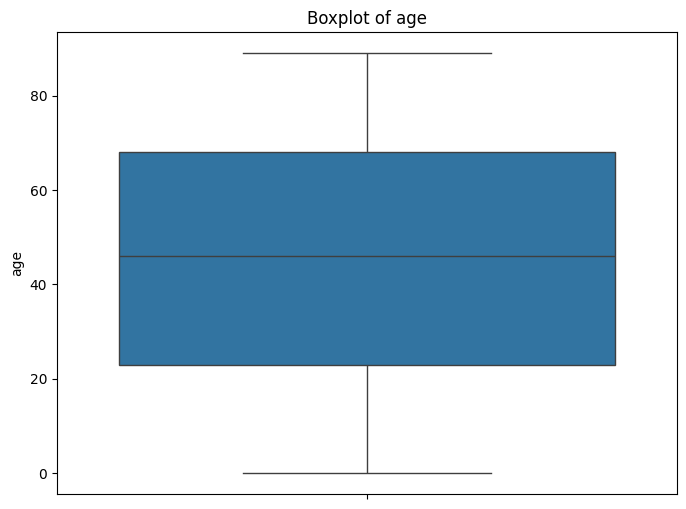

In [41]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['age'])
plt.title('Boxplot of age')
plt.ylabel('age')
plt.show()

#**Eksplorassi Data (EDA)**

#**Comparison(Perbandingan)**

Comparison digunakan untuk membandingkan dua atau lebih kategori atau kelompok data.

Tujuannya: Mengetahui kategori mana yang paling dominan, Membandingkan performa atau jumlah antar kelompok

Contoh visuanya, Bar Chart:
* rata-rata length_of_stay per dapartemen
* rata-rata statisfaction per gender

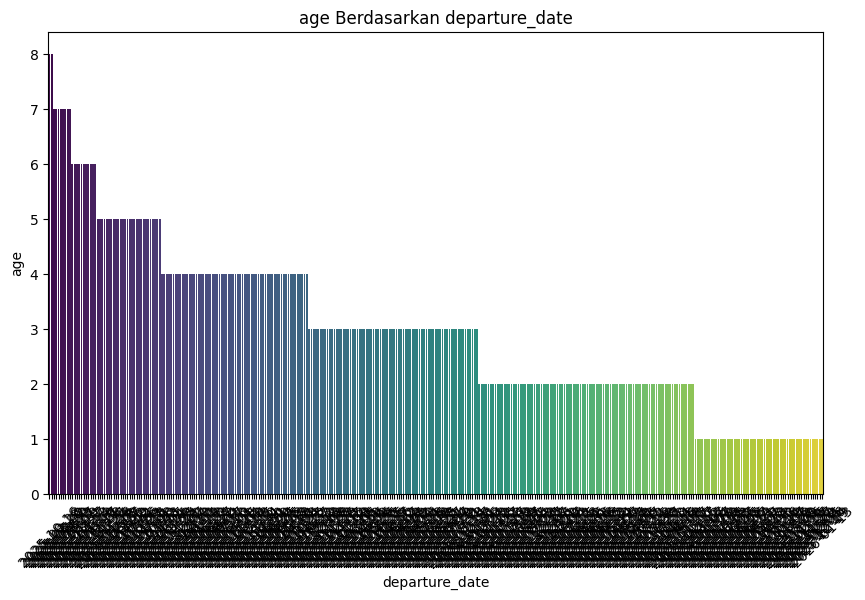

In [42]:
age_departure_date = df.groupby('departure_date')['age'].count().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=age_departure_date.index, y=age_departure_date.values, palette='viridis', hue=age_departure_date.index, legend=False)
plt.title('age Berdasarkan departure_date')
plt.xlabel('departure_date')
plt.ylabel('age')
plt.xticks(rotation=45)
plt.show()

#**Composition(Komposisi)**

Composition adalah analisis untuk melihat proporsi atau persentase bagian dalam satu keseluruhan.
Biasanya menggunakan pie chart atau stacked bar chart.  Tujuannya yaitu:
* Mengetahui kontribusi tiap kategori terhadap total data
* Melihat struktur data secara keseluruhan.

Visualnya yaitu Pie Chart atau Bar Chart:
* Persentase Gender
* Persentase Admission_Type
* Persentase Department

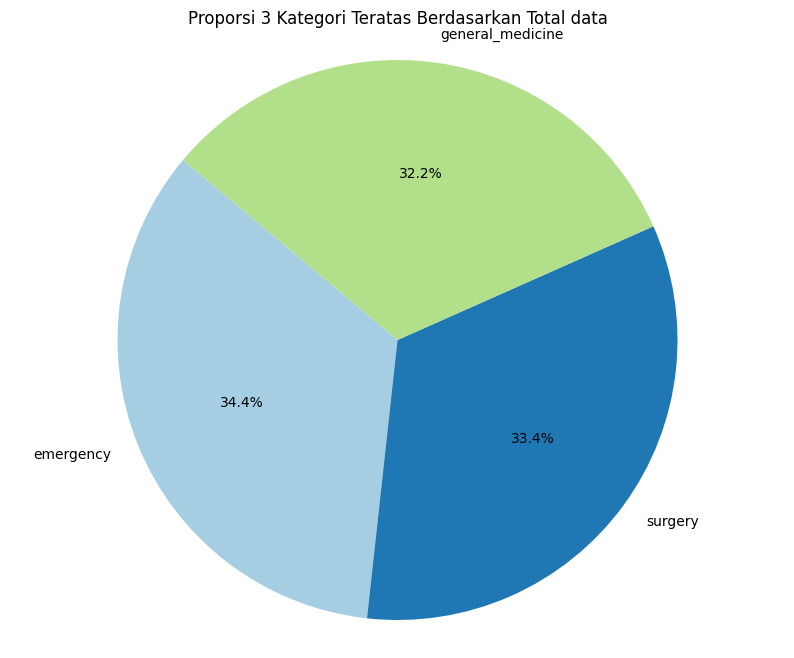

In [43]:
sales_by_service = df.groupby('service')['age'].sum().sort_values(ascending=False)
sales_by_service_top3 = sales_by_service.head(3)

plt.figure(figsize=(10, 8))
sales_by_service_top3.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Proporsi 3 Kategori Teratas Berdasarkan Total data')
plt.ylabel('')
plt.axis('equal')
plt.show()

#**Distribution(Distribusi)**

Distribution adalah analisis untuk melihat sebaran nilai numerik.
Biasanya menggunakan histogram atau boxplot.

Tujuannya:
* Mengetahui pola data (normal, miring, dll)
* Melihat nilai ekstrem (outliers)
* Mengetahui rentang dan sebaran data

contoh visualnya
Histogram atau Boxplot:
* Distribusi Age
* Distribusi Length_of_Stay
* Distribusi Satisfaction

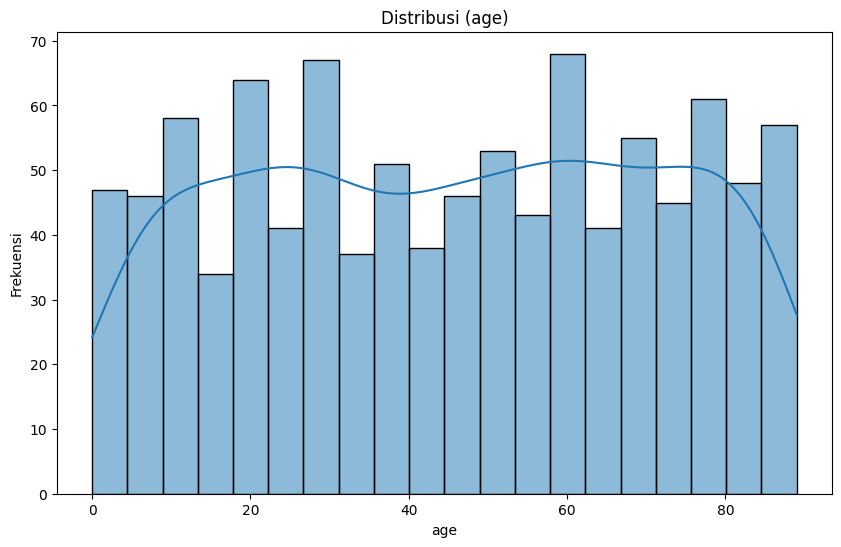

In [44]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], bins=20, kde=True)
plt.title('Distribusi (age)')
plt.xlabel('age')
plt.ylabel('Frekuensi')
plt.show()

#**Relationship(Hubungan)**

analisis untuk melihat hubungan antara dua atau lebih variabel.
Biasanya menggunakan scatter plot atau correlation heatmap.
Tujuan:
* Mengetahui variabel yang saling mempengaruhi
* Mencari pola atau korelasi dalam data
Visualnya:
Scatter Plot atau Heatmap Korelasi:
* Age vs Length_of_Stay
* Length_of_Stay vs Satisfaction

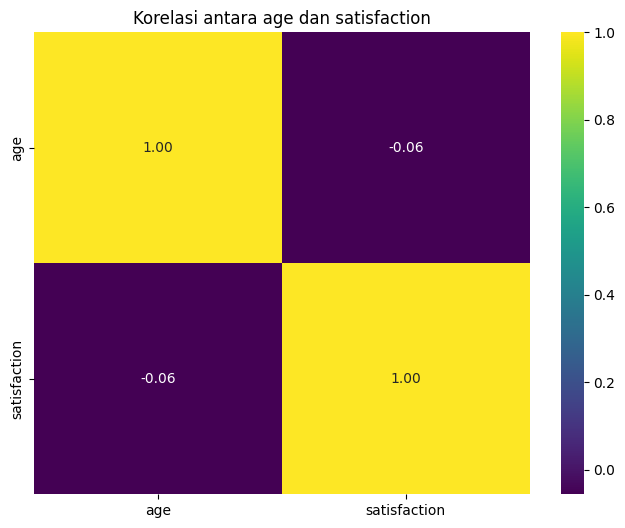

In [45]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['age', 'satisfaction']].corr(),
            annot=True,
            cmap='viridis',
            fmt='.2f')
plt.title('Korelasi antara age dan satisfaction')
plt.show()

#**Data Preparation**

##**Penanganan Type Data**

**1. Departure Date**

In [46]:
df["departure_date"] = pd.to_datetime(df["departure_date"], format="mixed")
df["departure_date"].head(5)

,departure_date
0,2025-03-22
1,2025-12-14
2,2025-07-05
3,2025-10-23
4,2025-02-25


**2. Arrival Date**

In [47]:
df["arrival_date"] = pd.to_datetime(df["arrival_date"], format="mixed")
df["arrival_date"].head(5)

,arrival_date
0,2025-03-16
1,2025-12-13
2,2025-06-29
3,2025-10-12
4,2025-02-18


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   patient_id      1000 non-null   object        
 1   name            1000 non-null   object        
 2   age             1000 non-null   int64         
 3   arrival_date    1000 non-null   datetime64[ns]
 4   departure_date  1000 non-null   datetime64[ns]
 5   service         1000 non-null   object        
 6   satisfaction    1000 non-null   int64         
dtypes: datetime64[ns](2), int64(2), object(3)
memory usage: 54.8+ KB


Jadi diatas ada data yang salah, yaitu seharusnya tipe datanya berupa datetime, tetapi malah object, maka dibawah ini menggunakan penanganan type data untuk memperbaikinya.

#**Incosistent values**

Tahap penanganan Inconsistent Values tidak diperlukan karena memang dalam dataset ini sudah konsisten, tidak ada bermasalah tau pun kenapa napa,nskema datanya stabil, tidak ada yang perlu baikin lagi.

#**Massing value**

Penanganan Misssing Values tidak diperlukan, karena
Data tidak ada yang hilang datanya sangat lengkap, integrasi datanya sempurna.
- Efisiensi alur kerja tetap ringkas tanpa langkah redundan yang tidak memberikan perubahan pada kualitas data
- Data derasal dari sumber terverifikasi


#**Duplicated Values**
Tidak ada yang terduplikat, atau data nya ganda di data saya, dengan data bersih ini, menjadi efisiensi komputasi.


#**Outliers**

- Data Masih dalam Rentang Logis
- Keandalan Sumber Data
Karna edata berasal dari sistem yang sudah terverifikasi, nilai-nilai ekstrem yang muncul diperlakukan sebagai fakta lapangan (kejadian nyata), bukan sebagai kesalahan input atau noise yang harus dibuang.
Dataset ini sangat bersih. Tidak ada data "sampah" seperti usia 200 tahun atau skor kepuasan 500. Satu-satunya yang perlu dipastikan adalah apakah usia 0 itu valid untuk unit layanan yang bersangkutan (misal: ICU atau Emergency)


##**Kontruksi Data (Contruct Data)**

Saya tidak menggunakan kontruksi data ini karena data saya sudah memenuhi kebutuhan analisis kolom-kolom yang ada saat ini sudah cukup untuk menjawab pertanyaan riset atau tujuan bisnis ini. data ini sudah memiliki header yang jelas di baris pertama. Karena nama kolomnya sudah standar (seperti id, nama, diagnosis), sistem tidak perlu lagi dikonstruksi ulang untuk mengenali jenis informasinya.


##**Reduksi Data (Data Reduction)**

Reduksi data biasanya dilakukan jika ukuran file mencapai Gigabyte atau Terabyte yang memberatkan memori. Karena file patients.csv saya ukurannya relatif kecil (skala kilobyte/megabyte), proses reduksi justru akan membuang-buang waktu (overhead) tanpa memberikan peningkatan performa yang signifikan.
melakukan reduksi berisiko menghilangkan korelasi penting yang dibutuhkan untuk analisis mendalam di masa depan. jadi saya ingin menjaga akurasi 100% dari sumber aslinya.Mempertahankan seluruh dimensi dan record data sangat penting untuk menjaga integritas informasi dan menghindari risiko hilangnya variabel prediktor yang krusial bagi analisis medis di tahap selanjutnya.

##**MATPLOTLIP & SEABORN**

#**Bar Chart**

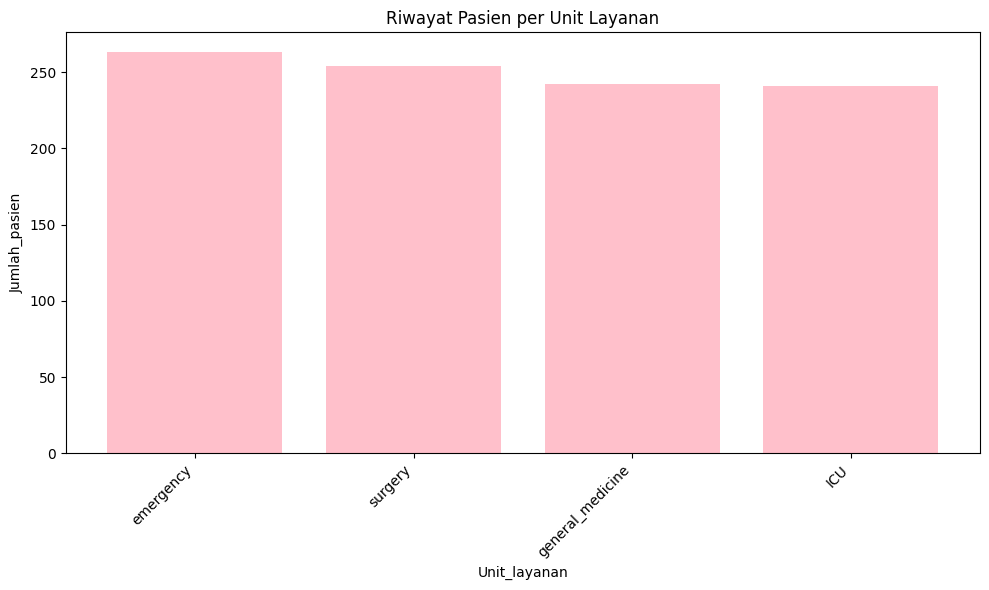

In [83]:
jumlah_pasien_per_unit = df['service'].value_counts().head(5).sort_values(ascending=False) # head() jumlah yang mau ditampilkan & Urutan

plt.figure(figsize=(10, 6)) # Ukuran
plt.bar(jumlah_pasien_per_unit.index, jumlah_pasien_per_unit.values, color='pink') # color warna
plt.xlabel('Unit_layanan') # keterangan X label
plt.ylabel('Jumlah_pasien') # keterangan y label
plt.title('Riwayat Pasien per Unit Layanan') # Judul
plt.xticks(rotation=45, ha='right') # rotasi teks
plt.tight_layout()
plt.show()

Insight: Lihat potongan yang paling lebar. Jika bagian Emergency adalah yang paling besar, artinya rumah sakit kamu lebih banyak menangani kasus darurat daripada pasien kontrol biasa.
Action: Jika potongan General Medicine mencapai 50% lebih, rumah sakit harus menempatkan lebih banyak perawat dan meja pendaftaran di sana agar tidak terjadi antrean panjang.

#**Pie Chart**

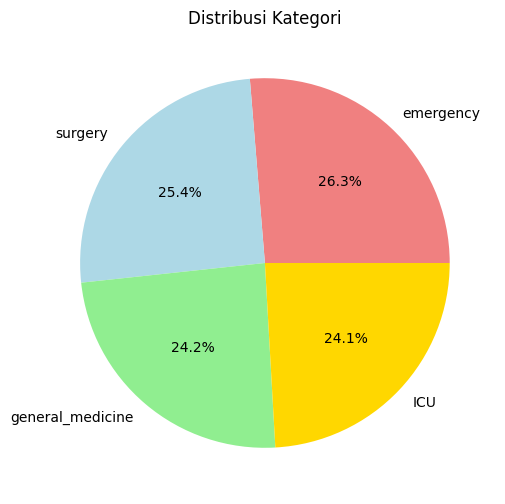

In [59]:
# Pie Chart (Matplotlib) (HANYA 1 KOLOM)
plt.figure(figsize=(10, 6)) # ukuran
plt.pie(df['service'].value_counts(), labels=df['service'].value_counts().index, autopct='%1.1f%%', colors=['lightcoral', 'lightblue', 'lightgreen', 'gold']) # colors (warna)
plt.title('Distribusi Kategori') # Judul
plt.show()

Insight: Perbandingan Langsung: Kita bisa langsung tahu siapa juara 1 dan siapa yang paling sedikit tanpa harus melihat angka secara detail. Cukup lihat warna mana yang paling dominan di lingkaran tersebut.
Action: Untuk layanan yang potongannya sangat kecil (sangat sedikit pasien), manajemen bisa berpikir: "Apakah layanan ini kurang dipromosikan? Atau memang peminatnya sedikit sehingga kita bisa pindahkan stafnya ke bagian yang lebih ramai?".

#**Line Chart**

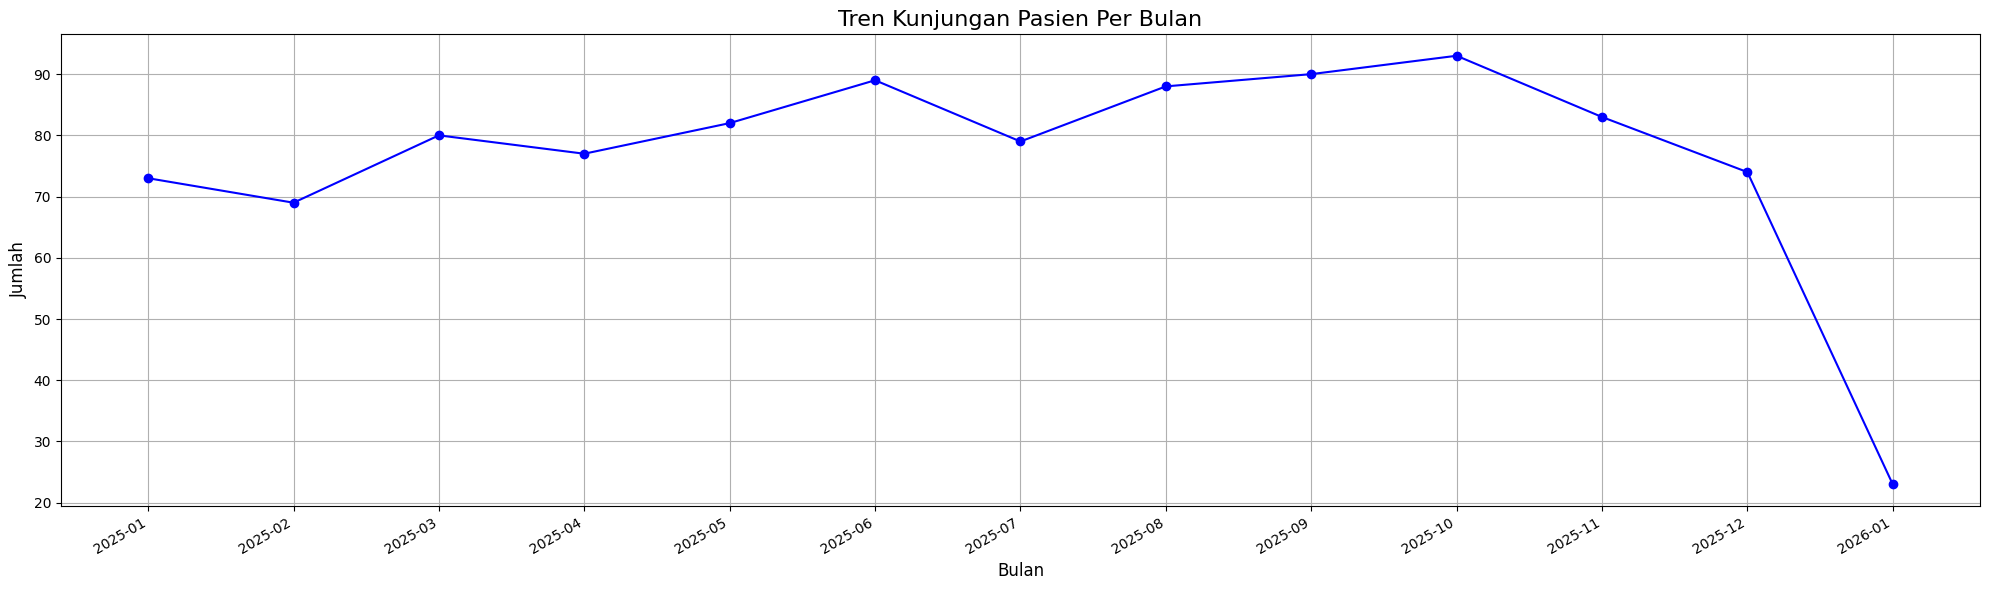

In [86]:
# Line Chart (Matplotlib)

# Pastikan kolom 'departure_date' bertipe datetime
df['departure_date'] = pd.to_datetime(df['departure_date'])

# Group by month
GrupPerBulan = df.groupby(df['departure_date'].dt.to_period('M')).size()

plt.figure(figsize=(20, 6)) # Ukuran figure diperbesar untuk kejelasan
plt.plot(GrupPerBulan.index.astype(str), GrupPerBulan.values, marker='o', color='blue') # Mengubah warna agar berbeda
plt.title('Tren Kunjungan Pasien Per Bulan', fontsize=16) # Judul
plt.xlabel('Bulan', fontsize=12) # X Keterangan
plt.ylabel('Jumlah', fontsize=12) # Y Keterangan
plt.grid(True)
plt.gcf().autofmt_xdate() # Otomatis mengatur format dan rotasi tanggal di sumbu X
plt.tight_layout()
plt.show()

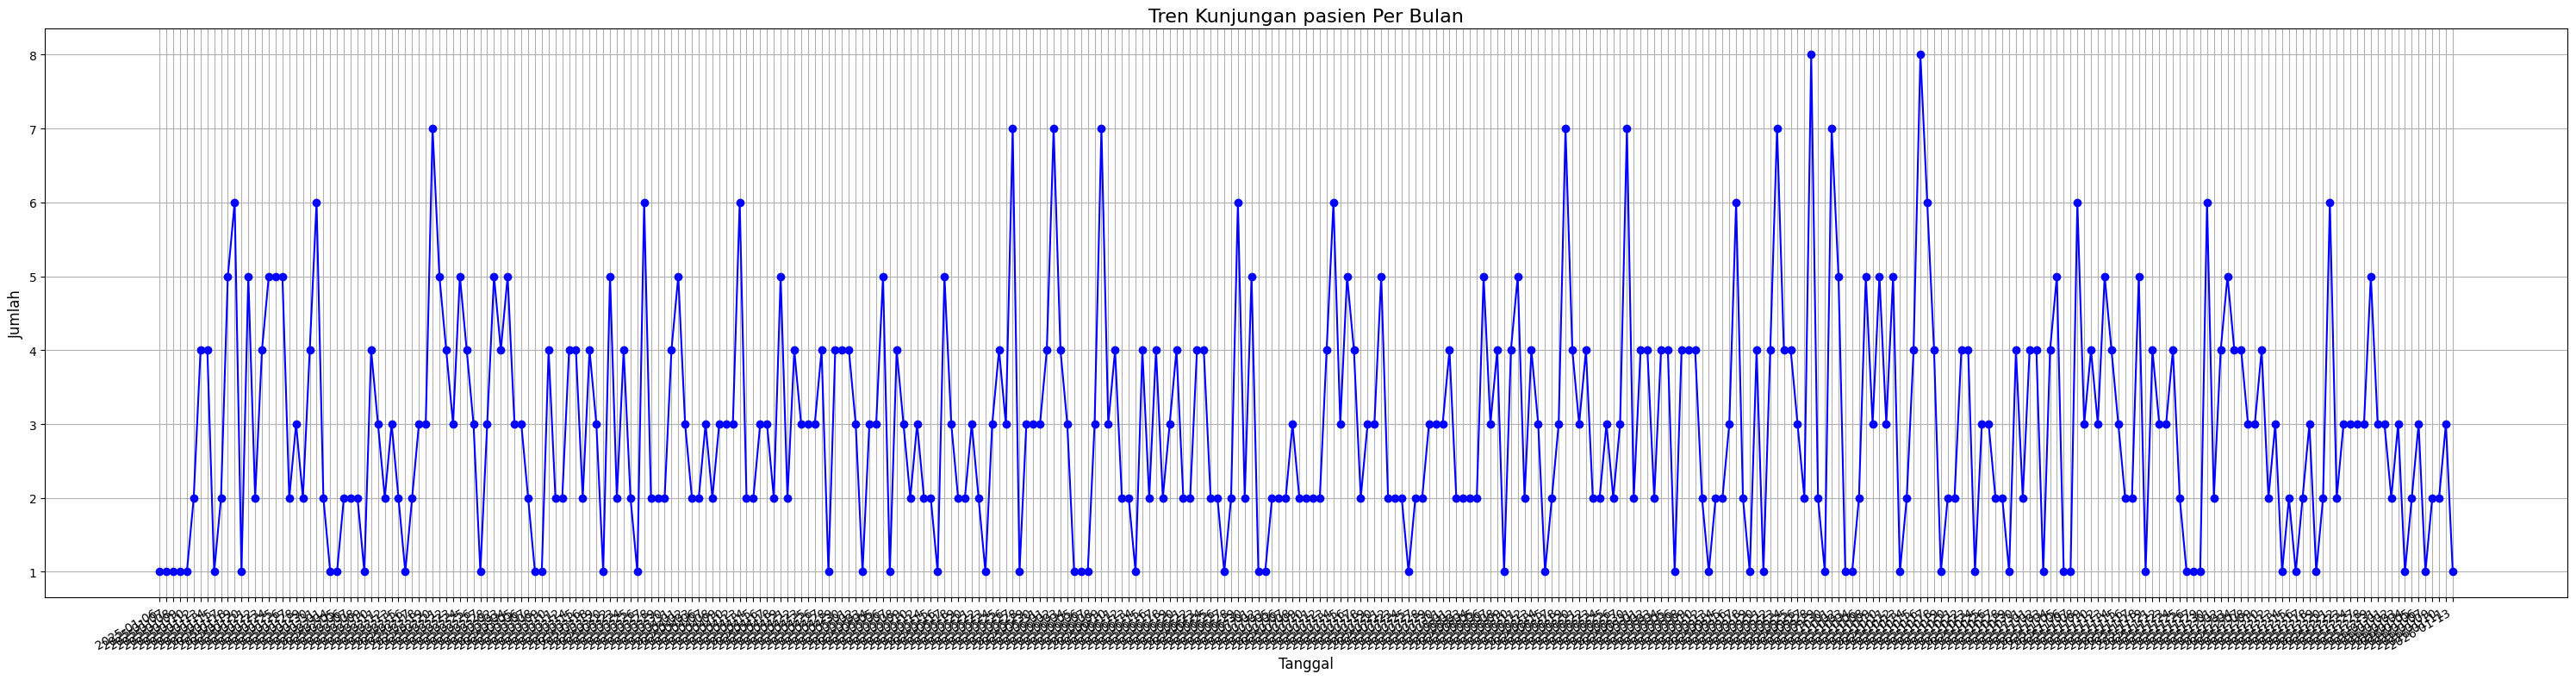

In [87]:
# Line Chart (Matplotlib)

# Pastikan kolom bertipe datetime

# Group by tanggal distribusi
VARIABEL1 = df.groupby(df['departure_date'].dt.to_period('D')).size()

plt.figure(figsize=(30, 8)) # Ukuran
plt.plot(VARIABEL1.index.astype(str), VARIABEL1.values, marker='o', color='blue') # Color = warna

plt.title('Tren Kunjungan pasien Per Bulan', fontsize=16) # Judul
plt.xlabel('Tanggal', fontsize=12) # X Keterangan
plt.ylabel('Jumlah', fontsize=12) # Y Keterangan

plt.grid(True)
plt.gcf().autofmt_xdate()
plt.tight_layout()

plt.show()

Sebenarnya saya masih binggung menggunakan yang tanggal atau bulan yang lebih tepat.
insight: Dilihat dari yang 12 bulan di tahun 2025 itu rata-rata nya semakin naik tetapi di 2026 itu dia turun derastis.
Action: berarti kenyaman pasien untuk datang ke rumah sakit ditahun 2025 sudah sayngat nyaman, di tahun 2026 harus lebih ditingkatkan pelayanan nya agar pasien bisa berobat dengan tenang dan nyaman.

#**Histogram**

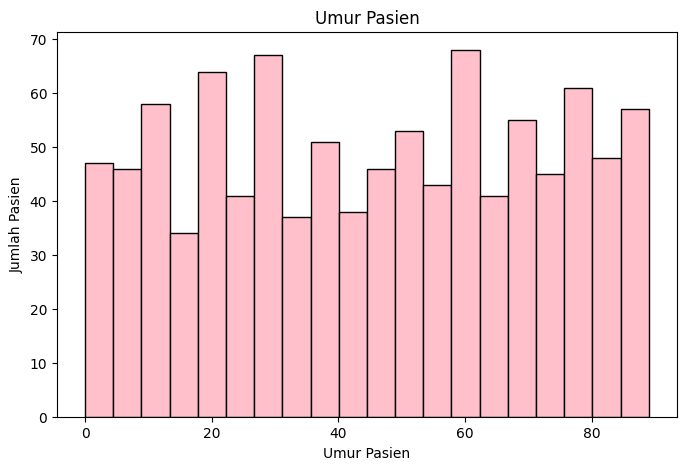

In [81]:
# Histogram (Matplotlib): Distribusi Penjualan
plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='pink', edgecolor='black')
plt.title('Umur Pasien')
plt.xlabel('Umur Pasien')
plt.ylabel('Jumlah Pasien')
plt.show()

Insight:Bisa dilihat apakah rumah sakit melayani semua umur secara merata atau hanya spesifik kelompok tertentu saja. Histogram menunjukkan di umur berapa pasien kita paling menumpuk:
Jika batangnya paling tinggi di angka 0-10 tahun, berarti rumah sakit kamu ramai oleh pasien anak-anak. Jika batangnya tinggi di angka 60-80 tahun, berarti mayoritas pasien adalah lansia.
Action:Jika ternyata pasien umur produktif (20-40 tahun) sangat sedikit, rumah sakit bisa membuat program medical check-up khusus karyawan kantor untuk menarik mereka. Jika gunungnya tinggi di umur tua, rumah sakit harus menambah dokter spesialis penyakit dalam atau geriatri. Jika banyak anak-anak, perbanyak spesialis anak (pediatri).

#**Boxplot**

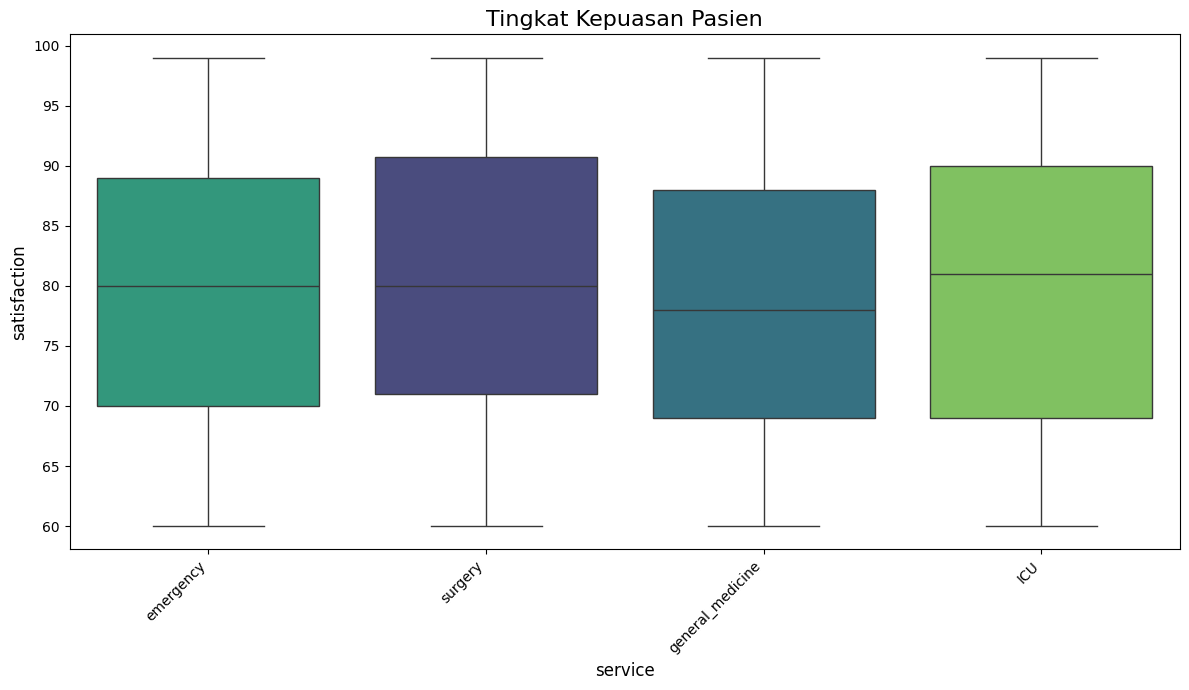

In [78]:
VARIABEL1 = df['service'].value_counts().head(5).index
VARIABEL2 = df[df['service'].isin(VARIABEL1)]

plt.figure(figsize=(12, 7)) # Ukuran figure
sns.boxplot(x='service', y='satisfaction', data=VARIABEL2, palette='viridis', order=VARIABEL1, hue='service', legend=False)
plt.title('Tingkat Kepuasan Pasien', fontsize=16) # Judul
plt.xlabel('service', fontsize=12) # X Keterangan
plt.ylabel('satisfaction', fontsize=12) # Y Keterangan
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Insight: Melihat dari layanan mana yang paling bermasalah. Kalau kotak Emergency (UGD) lebih rendah dibanding Surgery (Bedah), berarti pasien UGD kurang puas. Garis tengah di dalam kotak adalah nilai kepuasan yang paling sering muncul.

Action: Jika kepuasan di UGD rendah, rumah sakit harus menambah kursi tunggu atau mempercepat proses administrasi.

#**ScatterPlot**

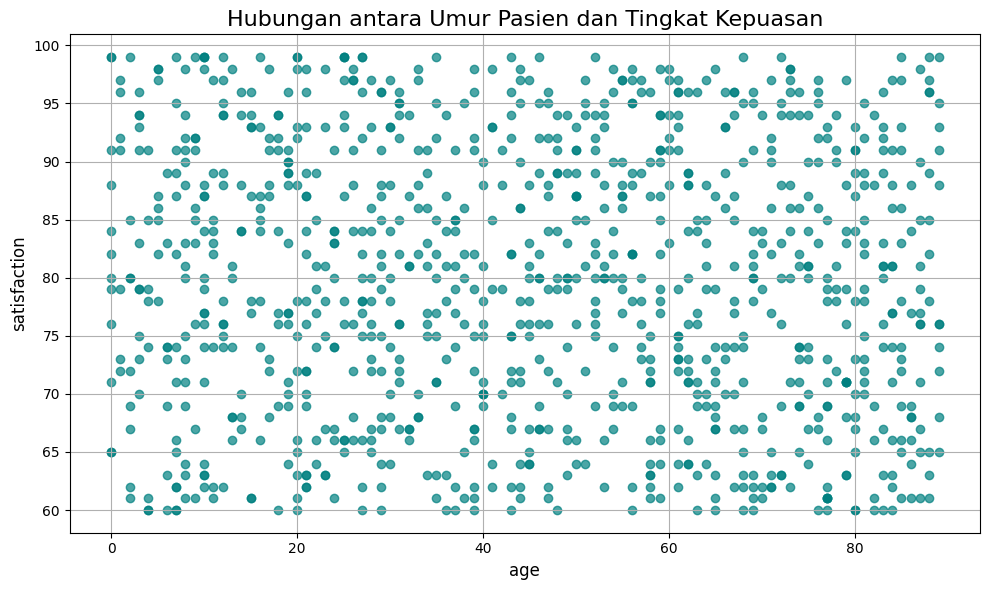

In [98]:
plt.figure(figsize=(10, 6)) # Ukuran
plt.scatter(df['age'], df['satisfaction'], alpha=0.7, color='teal') # Color (Warna)
plt.title('Hubungan antara Umur Pasien dan Tingkat Kepuasan', fontsize=16) # Judul
plt.xlabel('age', fontsize=12) # X Keterangan
plt.ylabel('satisfaction', fontsize=12) # Y Keterangan
plt.grid(True)
plt.tight_layout()
plt.show()

Insight: jikalau titik-titiknya berkumpul membentuk garis miring ke atas, artinya semakin tua pasien, semakin puas mereka. Jika menyebar berantakan, berarti umur tidak menentukan kebahagiaan pasien.
titik-titiknya berkumpul membentuk garis miring ke atas, artinya semakin tua pasien, semakin puas mereka. Jika menyebar berantakan, berarti umur tidak menentukan kebahagiaan pasien.

Action: Ketikatitik-titik warna tertentu (misal merah/Layanan Bedah) selalu berada di bawah, berarti ada masalah sistemik di bagian bedah yang harus segera diperbaiki oleh kepala rumah sakit.
terlihat pasien umur tertentu (misal 20-30 tahun) banyak memberi nilai rendah, rumah sakit harus mengubah gaya komunikasi staf agar lebih cocok dengan selera anak muda.

#**Heatmap**

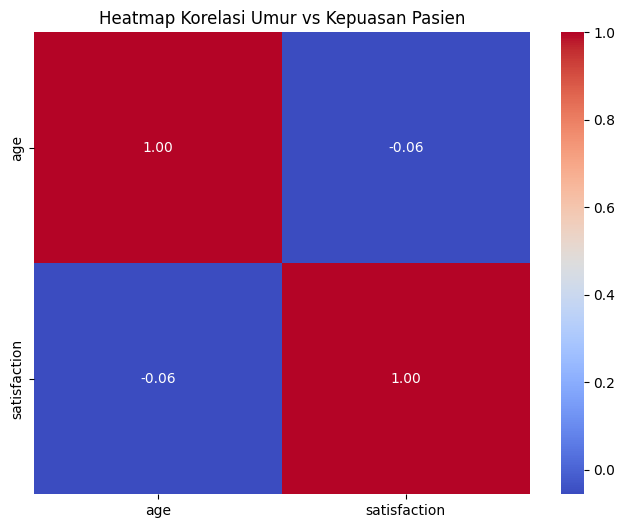

In [96]:
plt.figure(figsize=(8, 6))
sns.heatmap(data=df[['age', 'satisfaction']].corr(),
            annot=True,
            cmap='coo$warm',
            fmt='.2f')
plt.title('Heatmap Korelasi Umur vs Kepuasan Pasien')
plt.show()

Insight:
* Angka Korelasi: Nilainya berkisar dari -1 sampai 1.

Jika mendekati 1: Hubungannya kuat searah (misal: makin tua pasien, makin puas mereka).

Jika mendekati 0: Tidak ada hubungan sama sekali (umur tidak menjamin orang puas atau tidak).

Jika mendekati -1: Hubungan terbalik (makin tua, makin tidak puas).

Warna: Semakin pekat warnanya, semakin kuat hubungannya.

Action:
*Evaluasi Target: Jika kamu melihat angka korelasi negatif yang besar antara umur dan kepuasan, artinya rumah sakit kamu gagal melayani lansia.

*Tindakan: Kamu harus menyarankan manajemen untuk melatih staf agar lebih ramah dan sabar saat menangani pasien berumur tua, atau memperbaiki fasilitas kursi roda dan aksesibilitas.

*Fokus Pelayanan: Jika tidak ada korelasi (angka mendekati 0), berarti kepuasan pasien ditentukan oleh hal lain, seperti kecepatan admin atau kebersihan kamar, bukan karena faktor usia.

#**Menyimpan Dataset**

In [97]:
df.to_csv('/content/drive/MyDrive/AVD/patients.csv', index=False)